<a href="https://colab.research.google.com/github/databykarinna/pengantar-data-sains/blob/main/Tugas_3_Pengantar_Data_Sains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Tugas di Kelas (mini-project 20–30 menit) — *Dataset Bebas***

1.  **Cari dataset publik** (Kaggle / UCI / Google Dataset Search / data.go.id).
**Syarat:** ✅
* ≥5 kolom
* Ada variabel numerik & kategorik
* Mengandung missing value atau potensi outlier

2. **Load data** ke DataFrame `df` ✅

3. **Identifikasi Struktur Data** ✅

* Observation (satu baris mewakili apa?)
* Variabel numerik
* Variabel kategorik

4. **Periksa Missing values** ✅
* Hitung jumlah missing per kolom
* Pilih salah satu: hapus atau imputasi
* Jelaskan alasan keputusan

5. **Deteksi Outlier** ✅

* Pilih satu variabel numerik utama
* Gunakan boxplot atau metode lain
* Tentukan apakah ada outlier
* Jelaskan apakah outlier dihapus atau dipertahankan


6. **Transformasi Data** ✅
*  Lakukan minimal satu transformasi pada variabel numerik
* Bandingkan distribusi sebelum dan sesudah transformasi.

7. **Penjelasan singkat** ✅

---

### **Output**

1. Tabel ringkasan missing
2. Bukti deteksi outlier
3. Grafik sebelum/sesudah transformasi
4. Interpretasi singkat

##**1. Dataset Publik**

Sumber data: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [17]:
# import library
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

##**2. Load data ke Data Frame (df)**

In [18]:
# menghubungkan google colab ke drive
from google.colab import drive
drive.mount('/content/drive')

# cek nama folder/file
!ls /content/drive/MyDrive/"Dataset PDS"/diabetes.csv

# Ambil Data untuk penanganan missing values
df = pd.read_csv('/content/drive/MyDrive/Dataset PDS/diabetes.csv')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/Dataset PDS/diabetes.csv'


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


##**3. Identifikasi Struktur Data**

In [19]:
# melihat info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [20]:
# Statistik deskriptif
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
# mengecek missing value
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


##**4. Memeriksa Missing Value**

In [22]:
# menghitung jumlah dan presentase nilai 0 pada setiap variabel
pd.DataFrame({
    'Jumlah Missing Value': (df == 0).sum(),
    'Persentase': (df == 0).sum()/len(df)*100})

,Jumlah Missing Value,Persentase
Pregnancies,111,14.453125
Glucose,5,0.651042
BloodPressure,35,4.557292
SkinThickness,227,29.557292
Insulin,374,48.697917
BMI,11,1.432292
DiabetesPedigreeFunction,0,0.000000
Age,0,0.000000
Outcome,500,65.104167


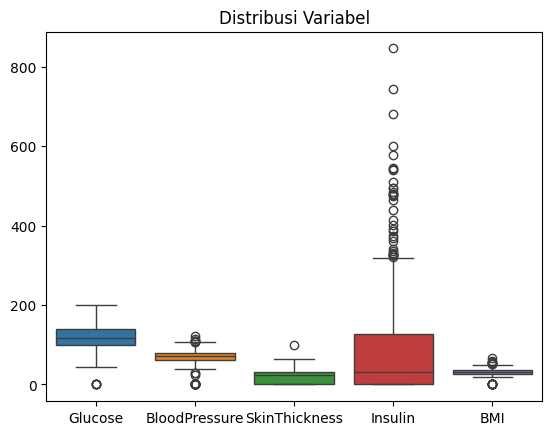

In [23]:
# melihat distribusi pada variabel yang terdapat missing value
# untuk menentukan imputasi nilai yang sesuai
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

sb.boxplot(data=df[cols])
plt.title("Distribusi Variabel")
plt.show()


In [24]:
# imputasi nilai mean dan median
## mengubah nilai nol menjadi NaN terlebih dahulu
df[cols]=df[cols].replace(0, np.nan)

## imputasi mean untuk variabel Glucose
df['Glucose'].fillna(df['Glucose'].mean(), inplace=True)

## imputasi median
df['BloodPressure'].fillna(df['BloodPressure'].median(), inplace=True)
df['SkinThickness'].fillna(df['SkinThickness'].median(), inplace=True)
df['Insulin'].fillna(df['Insulin'].median(), inplace=True)
df['BMI'].fillna(df['BMI'].median(), inplace=True)

/tmp/ipykernel_190/463624758.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Glucose'].fillna(df['Glucose'].mean(), inplace=True)
/tmp/ipykernel_190/463624758.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [25]:
# Mengecek hasil
pd.DataFrame({
    'Jumlah Missing Value': (df == 0).sum(),
    'Persentase': (df == 0).sum()/len(df)*100})

,Jumlah Missing Value,Persentase
Pregnancies,111,14.453125
Glucose,0,0.000000
BloodPressure,0,0.000000
SkinThickness,0,0.000000
Insulin,0,0.000000
BMI,0,0.000000
DiabetesPedigreeFunction,0,0.000000
Age,0,0.000000
Outcome,500,65.104167


In [26]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


##**5. Mendeteksi Outlier**

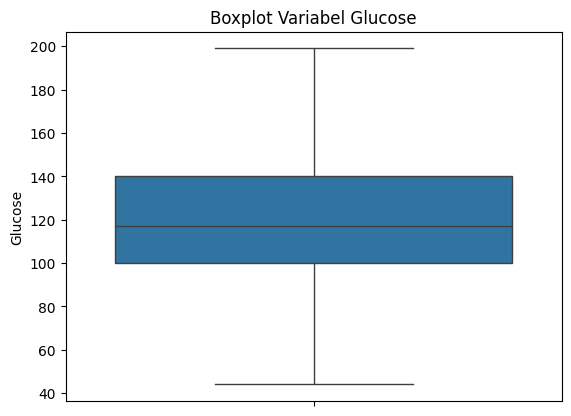

In [27]:
# melihat boxplot variabel Glucose
sb.boxplot(df['Glucose'])
plt.title('Boxplot Variabel Glucose')
plt.show()

##**6. Transformasi Data**

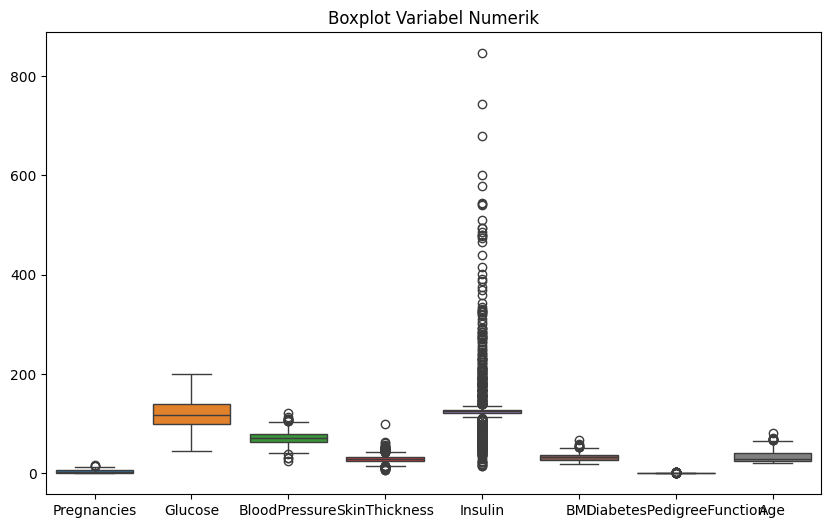

In [28]:
# melihat ditribusi seluruh variabel numerik
plt.figure(figsize=(10,6))

## menghapus variabel target
sb.boxplot(data=df.drop(columns=['Outcome']))

plt.title("Boxplot Variabel Numerik")
plt.show()

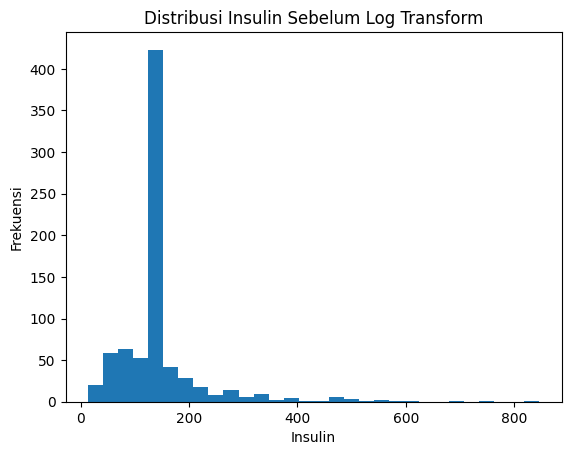

In [29]:
# melihat distribusi variabel insulin
plt.figure()
plt.hist(df['Insulin'], bins=30)
plt.title('Distribusi Insulin Sebelum Log Transform')
plt.xlabel('Insulin')
plt.ylabel('Frekuensi')
plt.show()

In [30]:
# melakukan transformasi pada variabel insulin
df['Insulin_log'] = np.log1p(df['Insulin'])

print("Skewness setelah log:", df['Insulin_log'].skew())

Skewness setelah log: -0.17507805732972928


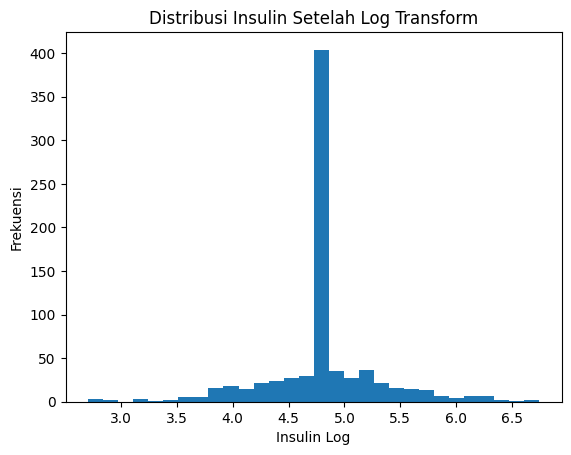

In [31]:
# melihat distribusi setelah transformasi
plt.figure()
plt.hist(df['Insulin_log'], bins=30)
plt.title('Distribusi Insulin Setelah Log Transform')
plt.xlabel('Insulin Log')
plt.ylabel('Frekuensi')
plt.show()